# kitscenes — Sensor Data Demo

This notebook demonstrates the `SensorDataLoader` and frame-level visualization helpers from `kitscenes`:

1. Creating a `KITScenesDataset` and `SensorDataLoader` for a scene
2. Discovering available sensors and timestamps
3. Loading camera, LiDAR, and radar sensor data directly from the loader
4. Building a `Frame` for frame-level inspection
5. Checking LiDAR deskewing and radar ego-motion compensation
6. Rendering LiDAR and radar with the provided visualization pipeline

**Prerequisite:** Set `DATASET_ROOT` below to point at a dataset root containing one or more scene directories.

In [20]:
# -- Configuration --------------------------------------------------------
# Option A: Set the env var (recommended for reuse):
#   export KITSCENES_ROOT=/path/to/kitscenes/root
#
# Option B: Hard-code the path here (has to be an absolute path):
DATASET_ROOT = "/tmp/fehler/ratarmount/kitscenes"
SCENE_ID = "c34c778f-ad8c-0aa9-7e1a-c86a73f887c7"  # sample val scene
%matplotlib inline

## 1. Load the dataset and create a SensorDataLoader

In [21]:
from kitscenes import KITScenesDataset

ds = KITScenesDataset(root=DATASET_ROOT, split=None)

if SCENE_ID not in ds.scene_ids:
    raise ValueError(
        f"Scene {SCENE_ID!r} not found. Available: {ds.scene_ids[:5]}..."
    )

scene = ds.get_scene(SCENE_ID)
loader = ds.get_sensor_loader(SCENE_ID)

print(f"Scene: {scene.scene_id}")
print(f"Scene path: {loader.scene_path}")

Scene: c34c778f-ad8c-0aa9-7e1a-c86a73f887c7
Scene path: /tmp/fehler/ratarmount/kitscenes/data/val/c34c778f-ad8c-0aa9-7e1a-c86a73f887c7


## 2. Discover available sensors

In [22]:
cameras = loader.get_camera_names()
lidars = loader.get_lidar_names()
radars = loader.get_radar_names()

print(f"Cameras ({len(cameras)}): {cameras}")
print(f"LiDARs  ({len(lidars)}):  {lidars}")
print(f"Radars  ({len(radars)}):  {radars}")
print(f"Total sensors: {len(loader.get_all_sensor_names())}")

Cameras (9): ['camera_base_front_center', 'camera_base_front_left_rect', 'camera_base_front_right_rect', 'camera_ring_front', 'camera_ring_front_left', 'camera_ring_front_right', 'camera_ring_rear', 'camera_ring_rear_left', 'camera_ring_rear_right']
LiDARs  (7):  ['lidar_top', 'lidar_front', 'lidar_left', 'lidar_right', 'lidar_rear', 'lidar_corner_left', 'lidar_corner_right']
Radars  (3):  ['radar_front', 'radar_left', 'radar_right']
Total sensors: 19


## 3. Timestamps

In [23]:
import numpy as np

# Reference timestamps
ref_ts = loader.get_reference_timestamps()
ref_ts_s = scene.timestamp_s
print(f"Reference timestamps: {ref_ts.shape[0]} frames")
print(f"  dtype: {ref_ts.dtype}")
print(f"  first (ns): {ref_ts[0]}")
print(f"  last  (ns): {ref_ts[-1]}")
print(f"  first (s):  {ref_ts_s[0]:.6f}")
print(f"  last  (s):  {ref_ts_s[-1]:.6f}")

Reference timestamps: 220 frames
  dtype: int64
  first (ns): 52000000
  last  (ns): 21952000000
  first (s):  0.052000
  last  (s):  21.952000


## 4. Camera calibration

In [24]:
if cameras:
    cam_name = cameras[0]
    calib = loader.get_camera_calibration(cam_name)
    print(f"Camera: {calib.sensor_name}")
    print(f"Intrinsic (3x3):")
    print(calib.intrinsic)
    print(f"\nExtrinsic (4x4) T_camera_to_reference:")
    print(calib.extrinsic)
    print(f"\nImage size from calibration: {calib.image_size}")
else:
    print("No cameras found in this scene.")

Camera: camera_base_front_center
Intrinsic (3x3):
[[3.022e+03 0.000e+00 2.924e+03]
 [0.000e+00 3.022e+03 1.545e+03]
 [0.000e+00 0.000e+00 1.000e+00]]

Extrinsic (4x4) T_camera_to_reference:
[[ 7.06487894e-03  4.19676304e-04  9.99974966e-01  4.21412528e-01]
 [-9.99948680e-01 -7.25710392e-03  7.06776977e-03  1.13009512e-02]
 [ 7.25987554e-03 -9.99973536e-01  3.68416309e-04 -3.83867800e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Image size from calibration: (5856, 3104)


## 5. Load and display a camera image

In [25]:
if cameras:
    cam_name = "camera_ring_front"
    frame_indices = loader.get_frame_indices(cam_name)
    print(f"{cam_name}: {len(frame_indices)} frames, "
          f"range [{frame_indices[0]}..{frame_indices[-1]}]")

    # Load the first available frame
    first_idx = frame_indices[0]
    img = loader.get_camera_image(cam_name, first_idx)
    print(f"Image shape: {img.shape}, dtype: {img.dtype}")

    # Also resolve the image size
    w, h = loader.get_camera_image_size(cam_name, first_idx)
    print(f"Image size: {w} x {h} (width x height)")

camera_ring_front: 220 frames, range [0..219]
Image shape: (2272, 3504, 3), dtype: uint8
Image size: 3504 x 2272 (width x height)


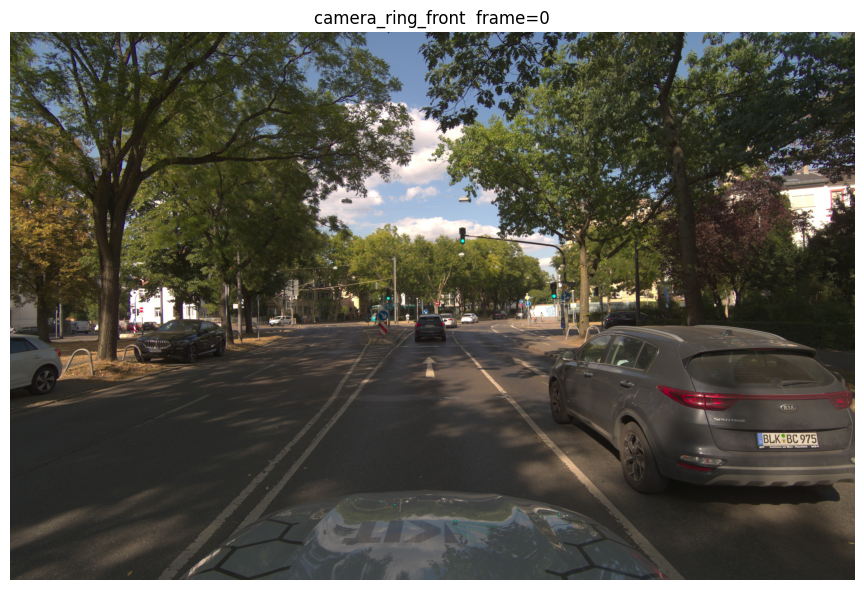

In [26]:
if cameras:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(img)
    ax.set_title(f"{cam_name}  frame={first_idx}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 6. Load a LiDAR sweep

In [27]:
if lidars:
    lidar_name = lidars[0]
    lidar_frames = loader.get_frame_indices(lidar_name)
    print(f"{lidar_name}: {len(lidar_frames)} frames, "
          f"range [{lidar_frames[0]}..{lidar_frames[-1]}]")

    sweep = loader.get_lidar_sweep(lidar_name, lidar_frames[0])
    print(f"\nLidarSweep:")
    print(f"  sensor_name:  {sweep.sensor_name}")
    print(f"  timestamp_ns: {sweep.timestamp_ns}")
    print(f"  points shape: {sweep.points.shape}")
    print(f"  points dtype: {sweep.points.dtype}")
    print(f"  fields:       {sweep.points.dtype.names}")
else:
    print("No LiDARs found in this scene.")

lidar_top: 220 frames, range [0..219]

LidarSweep:
  sensor_name:  lidar_top
  timestamp_ns: 52000000
  points shape: (211522,)
  points dtype: [('x', '<f4'), ('y', '<f4'), ('z', '<f4'), ('reflectivity', '<f4'), ('timestamp', '<f8'), ('ring', 'u1'), ('sensor_id', 'u1'), ('sensor_specific_data', '<u2')]
  fields:       ('x', 'y', 'z', 'reflectivity', 'timestamp', 'ring', 'sensor_id', 'sensor_specific_data')


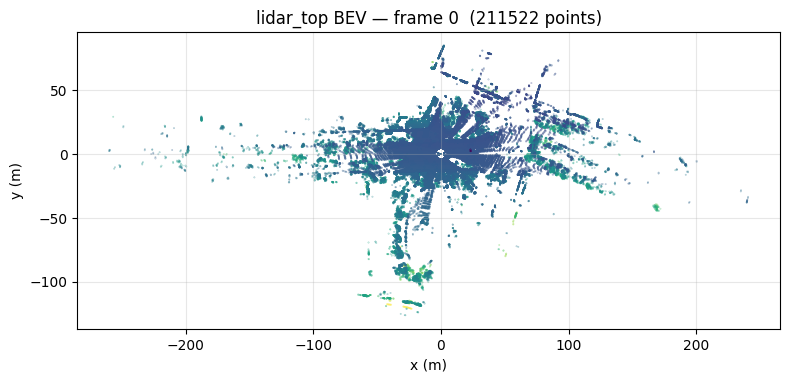

In [28]:
# Quick BEV scatter plot of the lidar points
if lidars:
    import matplotlib.pyplot as plt

    pts = sweep.points
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(pts["x"], pts["y"], s=0.1, c=pts["z"], cmap="viridis", alpha=0.5)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(f"{lidar_name} BEV — frame {lidar_frames[0]}  ({len(pts)} points)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Load a radar sweep

In [29]:
if radars:
    radar_name = radars[0]
    radar_frames = loader.get_frame_indices(radar_name)
    print(f"{radar_name}: {len(radar_frames)} frames, "
          f"range [{radar_frames[0]}..{radar_frames[-1]}]")

    rsweep = loader.get_radar_sweep(radar_name, radar_frames[0])
    print(f"\nRadarSweep:")
    print(f"  sensor_name:  {rsweep.sensor_name}")
    print(f"  timestamp_ns: {rsweep.timestamp_ns}")
    print(f"  points shape: {rsweep.points.shape}")
    print(f"  points dtype: {rsweep.points.dtype}")
    print(f"  fields:       {rsweep.points.dtype.names}")
else:
    print("No radars found in this scene.")

radar_front: 220 frames, range [0..219]

RadarSweep:
  sensor_name:  radar_front
  timestamp_ns: 52000000
  points shape: (556,)
  points dtype: [('x', '<f4'), ('y', '<f4'), ('z', '<f4'), ('azimuth', '<f4'), ('azimuth_std', '<f4'), ('elevation', '<f4'), ('elevation_std', '<f4'), ('range', '<f4'), ('range_std', '<f4'), ('range_rate', '<f4'), ('range_rate_std', '<f4'), ('rcs', '<f4'), ('timestamp', '<f8'), ('sensor_id', 'u1'), ('detection_id', '<u2')]
  fields:       ('x', 'y', 'z', 'azimuth', 'azimuth_std', 'elevation', 'elevation_std', 'range', 'range_std', 'range_rate', 'range_rate_std', 'rcs', 'timestamp', 'sensor_id', 'detection_id')


## 8. Frame index summary across all sensors

In [30]:
all_sensors = loader.get_all_sensor_names()
print(f"{'Sensor':<40} {'Frames':>8} {'First':>10} {'Last':>10}")
print("-" * 72)
for name in all_sensors:
    indices = loader.get_frame_indices(name)
    if indices:
        print(f"{name:<40} {len(indices):>8} {indices[0]:>10} {indices[-1]:>10}")
    else:
        print(f"{name:<40} {'(empty)':>8}")

Sensor                                     Frames      First       Last
------------------------------------------------------------------------
camera_base_front_center                      220          0        219
camera_base_front_left_rect                   220          0        219
camera_base_front_right_rect                  220          0        219
camera_ring_front                             220          0        219
camera_ring_front_left                        220          0        219
camera_ring_front_right                       220          0        219
camera_ring_rear                              220          0        219
camera_ring_rear_left                         220          0        219
camera_ring_rear_right                        220          0        219
lidar_top                                     220          0        219
lidar_front                                   220          0        219
lidar_left                                    220          0   

## 9. Build a `Frame` for frame-level inspection

The frame-level visualization helpers operate on `kitscenes.frame.Frame`, so we construct one from the current scene and reuse the existing `SensorDataLoader` for both LiDAR and radar examples below.

In [31]:
from kitscenes.frame import Frame

if len(scene.timestamps_ns) == 0:
    print("Scene has no reference timestamps.")
else:
    frame_idx = 0
    frame = Frame(
        scene_id=scene.scene_id,
        frame_idx=frame_idx,
        timestamp_ns=int(scene.timestamps_ns[frame_idx]),
        loader=loader,
        ego_poses=scene.ego_poses,
    )
    print(frame)
    print(f"timestamp_s:       {frame.timestamp_s:.3f}")
    print(f"ego_pose:          {frame.ego_pose}")
    print(f"available lidars:  {frame.available_lidar_names()}")
    print(f"available radars:  {frame.available_radar_names()}")
    print(f"available cameras: {frame.available_camera_names()}")

Frame(scene_id=c34c778f-ad8c-0aa9-7e1a-c86a73f887c7, frame_idx=0, timestamp_ns=52000000)
timestamp_s:       0.052
ego_pose:          EgoPose(timestamp_ns=51987886, translation=array([ -548.1616, -1050.2366,   146.7634]), rotation=array([0.0135, 0.0032, 0.4485, 0.8937]))
available lidars:  ['lidar_top', 'lidar_front', 'lidar_left', 'lidar_right', 'lidar_rear', 'lidar_corner_left', 'lidar_corner_right']
available radars:  ['radar_front', 'radar_left', 'radar_right']
available cameras: ['camera_base_front_center', 'camera_base_front_left_rect', 'camera_base_front_right_rect', 'camera_ring_front', 'camera_ring_front_left', 'camera_ring_front_right', 'camera_ring_rear', 'camera_ring_rear_left', 'camera_ring_rear_right']


## 10. LiDAR deskewing

This mirrors the playground check: inspect the default deskewed point cloud, compare it against the raw parquet payload, and summarize the size of the correction.

In [32]:
import numpy as np

if 'frame' not in globals():
    print("Run the frame-construction cell first.")
else:
    frame_lidar_names = frame.available_lidar_names()
    if frame_lidar_names:
        lidar_name = "lidar_top" if "lidar_top" in frame_lidar_names else frame_lidar_names[0]
        lidar_sweep = frame.lidar(lidar_name)
        if lidar_sweep is None:
            print(f"{lidar_name} is not available at this frame.")
        else:
            print(f"LiDAR deskewing ({lidar_name}, frame_idx={frame.frame_idx}):")
            print(f"  deskewed:      {lidar_sweep.deskewed}")
            print(f"  deskew_reason: {lidar_sweep.deskew_reason}")
            print(f"  total points:  {len(lidar_sweep.points)}")

            deskewed_xyz = np.column_stack([
                lidar_sweep.points["x"],
                lidar_sweep.points["y"],
                lidar_sweep.points["z"],
            ]).astype(np.float64)
            raw_xyz = np.column_stack([
                lidar_sweep.raw()["x"],
                lidar_sweep.raw()["y"],
                lidar_sweep.raw()["z"],
            ]).astype(np.float64)
            diff = np.linalg.norm(deskewed_xyz - raw_xyz, axis=1)

            valid = np.any(raw_xyz != 0.0, axis=1)
            print(f"  valid points:  {int(valid.sum())}")
            if valid.any():
                print(f"  max correction (m):    {diff[valid].max():.4f}")
                print(f"  mean correction (m):   {diff[valid].mean():.4f}")
                print(f"  median correction (m): {np.median(diff[valid]):.4f}")
                if lidar_sweep.deskewed and diff[valid].mean() > 0.0:
                    print("  [OK] deskewing produced non-zero corrections.")
            else:
                print("  No non-zero raw points found for correction statistics.")

            arrays_share_memory = np.shares_memory(
                lidar_sweep.points["x"],
                lidar_sweep.raw()["x"],
            )
            print(f"  raw/deskewed arrays share memory: {arrays_share_memory}")
            if not arrays_share_memory:
                print("  [OK] raw() and points are independent arrays.")
    else:
        print("No LiDARs are available for this frame.")

LiDAR deskewing (lidar_top, frame_idx=0):
  deskewed:      True
  deskew_reason: None
  total points:  211522
  valid points:  208157
  max correction (m):    0.6115
  mean correction (m):   0.1278
  median correction (m): 0.0001
  [OK] deskewing produced non-zero corrections.
  raw/deskewed arrays share memory: False
  [OK] raw() and points are independent arrays.


## 11. LiDAR visualizations

These plots reuse the provided frame-level visualization helpers instead of the earlier ad hoc scatter plot, so the LiDAR examples follow the same pipeline as the playground and the radar section below.

render_lidar_bev


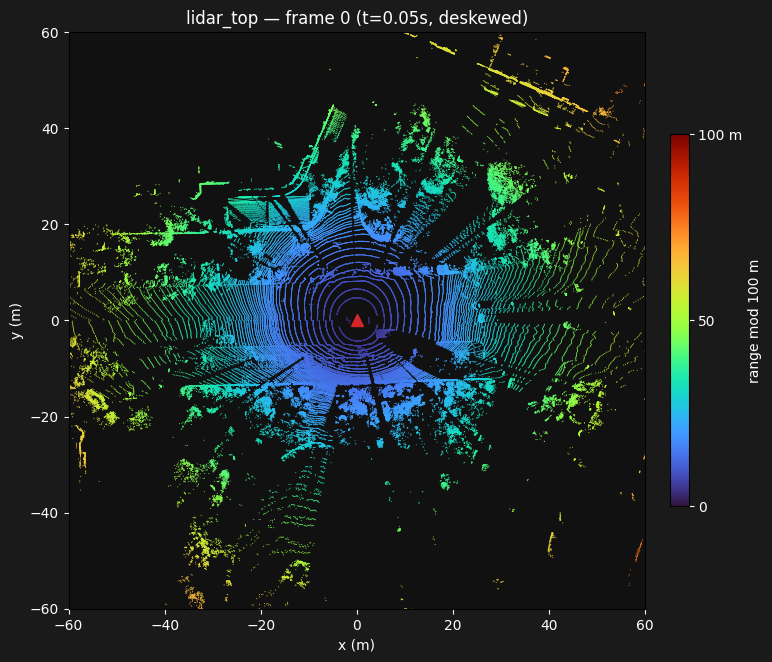

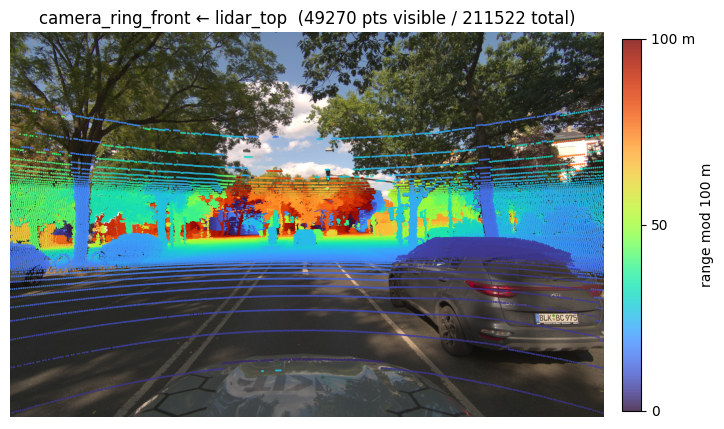

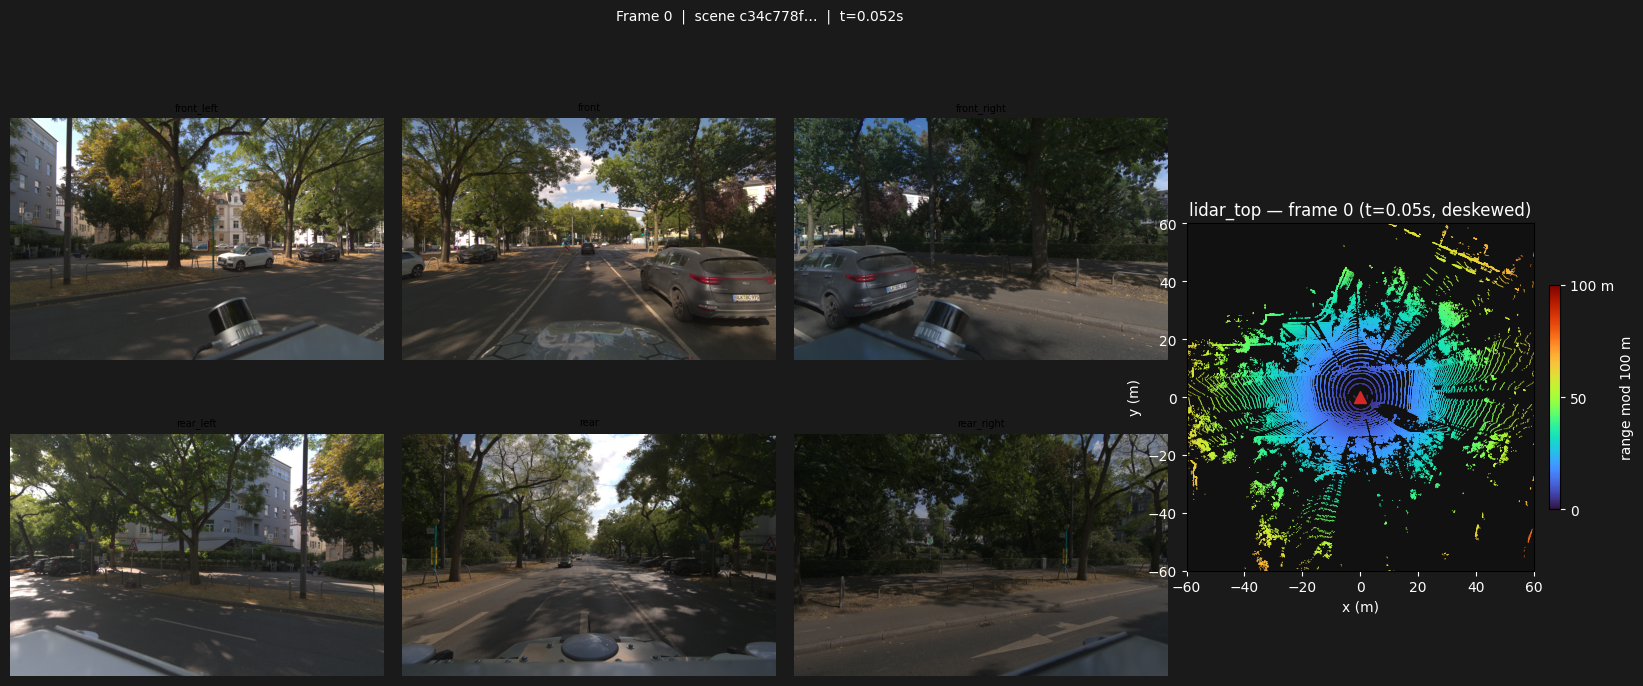

In [33]:
import matplotlib.pyplot as plt
from kitscenes.visualization import (
    render_frame_overview,
    render_lidar_bev,
    render_lidar_on_camera,
)
%matplotlib inline
if 'frame' not in globals():
    print("Run the frame-construction cell first.")
else:
    frame_lidar_names = frame.available_lidar_names()
    if frame_lidar_names:
        lidar_name = "lidar_top" if "lidar_top" in frame_lidar_names else frame_lidar_names[0]
        if frame.lidar(lidar_name) is None:
            print(f"{lidar_name} is not available at this frame.")
        else:
            fig, ax = render_lidar_bev(frame, lidar_name=lidar_name, range_m=60.0)
            print("render_lidar_bev")
            plt.show()
            plt.close(fig)

            cam_names = frame.available_camera_names()
            if cam_names:
                camera_name = "camera_ring_front" if "camera_ring_front" in cam_names else cam_names[0]
                fig, ax = render_lidar_on_camera(frame, camera_name, lidar_name=lidar_name)
                plt.show()
                plt.close(fig)
            else:
                print("No cameras available, skipping lidar_on_camera.")

            fig, axes = render_frame_overview(
                frame,
                lidar_name=lidar_name,
                show_radar=False,
                range_m=60.0,
            )
            plt.show()
            plt.close(fig)
    else:
        print("No LiDARs are available for this frame.")

## 12. Radar ego-motion compensation

This mirrors the playground check: compare the compensated `range_rate` values against the raw parquet values and inspect how large the correction is across detections. The radar point coordinates remain in each radar sensor's local frame.

In [34]:
import numpy as np
%matplotlib inline

if 'frame' not in globals():
    print("Run the previous frame-construction cell first.")
else:
    frame_radar_names = frame.available_radar_names()
    if frame_radar_names:
        radar_name = frame_radar_names[0]
        radar = frame.radar(radar_name)
        print(f"Radar ego-motion compensation ({radar_name}, frame_idx={frame.frame_idx}):")
        print(f"  compensated:         {radar.ego_motion_compensated}")
        print(f"  compensation_reason: {radar.compensation_reason}")
        print(f"  num detections:      {len(radar.points)}")

        pts = radar.points
        raw_pts = radar.raw()

        ranges = np.linalg.norm(
            np.column_stack([pts["x"], pts["y"], pts["z"]]).astype(np.float64), axis=1
        )
        rr_raw = raw_pts["range_rate"].astype(np.float64)
        rr_comp = pts["range_rate"].astype(np.float64)
        correction = rr_comp - rr_raw

        print(f"  range_rate raw  — mean={rr_raw.mean():.3f}, std={rr_raw.std():.3f} m/s")
        print(f"  range_rate comp — mean={rr_comp.mean():.3f}, std={rr_comp.std():.3f} m/s")
        print(f"  correction      — mean={correction.mean():.3f}, max_abs={np.abs(correction).max():.3f} m/s")

        far_mask = ranges > 50.0
        near_mask = ranges <= 50.0
        if far_mask.any() and near_mask.any():
            print(f"  |correction| near (<= 50 m): mean={np.abs(correction[near_mask]).mean():.3f} m/s")
            print(f"  |correction| far  (>  50 m): mean={np.abs(correction[far_mask]).mean():.3f} m/s")
    else:
        print("No radars are available for this frame.")

Radar ego-motion compensation (radar_front, frame_idx=0):
  compensated:         True
  compensation_reason: None
  num detections:      556
  range_rate raw  — mean=-9.109, std=2.290 m/s
  range_rate comp — mean=0.578, std=2.315 m/s
  correction      — mean=9.687, max_abs=10.302 m/s
  |correction| near (<= 50 m): mean=9.119 m/s
  |correction| far  (>  50 m): mean=9.882 m/s


Sensor           raw mean   raw std   comp mean   comp std   correction mean
---------------------------------------------------------------------------
radar_front        -9.109     2.290       0.578      2.315             9.687
radar_left          5.690     4.548       0.183      1.674            -5.507
radar_right         5.704     3.456       0.025      1.699            -5.680


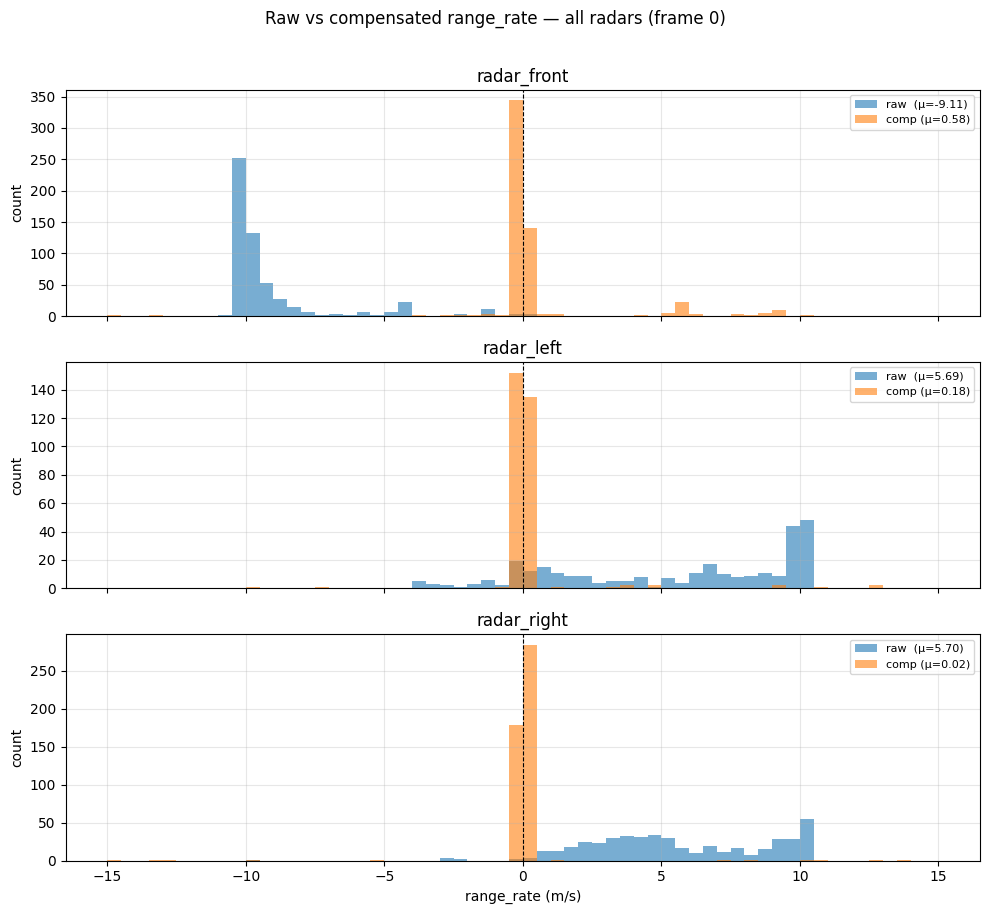

In [35]:

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Compare raw vs compensated range_rate for all three radars.
#
# Physical expectation for a vehicle moving mostly forward:
#   radar_front  → boresight ≈ forward  → raw ≈ -v_ego, corrected ≈ 0
#   radar_left   → boresight ≈ sideways → raw ≈ 0,      corrected ≈ 0
#   radar_right  → boresight ≈ sideways → raw ≈ 0,      corrected ≈ 0
#
# If compensation is correct, ALL three should have compensated mean ≈ 0.
# A non-zero compensated mean on radar_left / radar_right signals a bug.

if 'frame' not in globals():
    print("Run the frame-construction cell first.")
else:
    radar_names = frame.available_radar_names()
    fig, axes = plt.subplots(len(radar_names), 1, figsize=(10, 3 * len(radar_names)), sharex=True)
    if len(radar_names) == 1:
        axes = [axes]

    print(f"{'Sensor':<14}  {'raw mean':>9}  {'raw std':>8}  {'comp mean':>10}  {'comp std':>9}  {'correction mean':>16}")
    print("-" * 75)

    for ax, rname in zip(axes, radar_names):
        rsweep = frame.radar(rname)
        if rsweep is None:
            ax.set_title(f"{rname} — not available")
            continue

        rr_raw  = rsweep.raw()["range_rate"].astype(np.float64)
        rr_comp = rsweep.points["range_rate"].astype(np.float64)
        corr    = rr_comp - rr_raw

        print(
            f"{rname:<14}  {rr_raw.mean():>9.3f}  {rr_raw.std():>8.3f}"
            f"  {rr_comp.mean():>10.3f}  {rr_comp.std():>9.3f}  {corr.mean():>16.3f}"
        )

        bins = np.linspace(-15, 15, 61)
        ax.hist(rr_raw,  bins=bins, alpha=0.6, label=f"raw  (μ={rr_raw.mean():.2f})")
        ax.hist(rr_comp, bins=bins, alpha=0.6, label=f"comp (μ={rr_comp.mean():.2f})")
        ax.axvline(0, color="k", lw=0.8, ls="--")
        ax.set_title(rname)
        ax.set_ylabel("count")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("range_rate (m/s)")
    plt.suptitle("Raw vs compensated range_rate — all radars (frame 0)", y=1.01)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## 13. Radar visualizations

These plots reuse the frame-level visualization helpers from the playground, but display them inline in the notebook instead of saving them to disk.

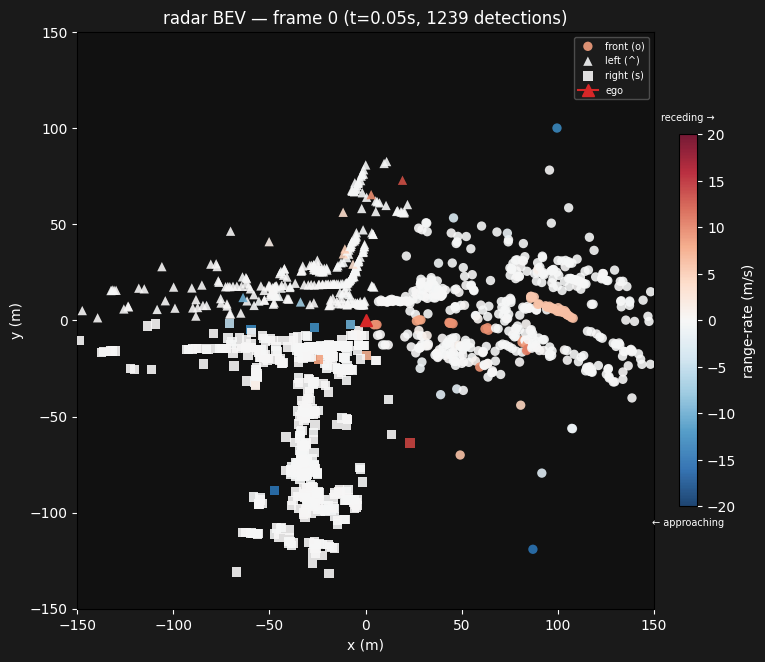

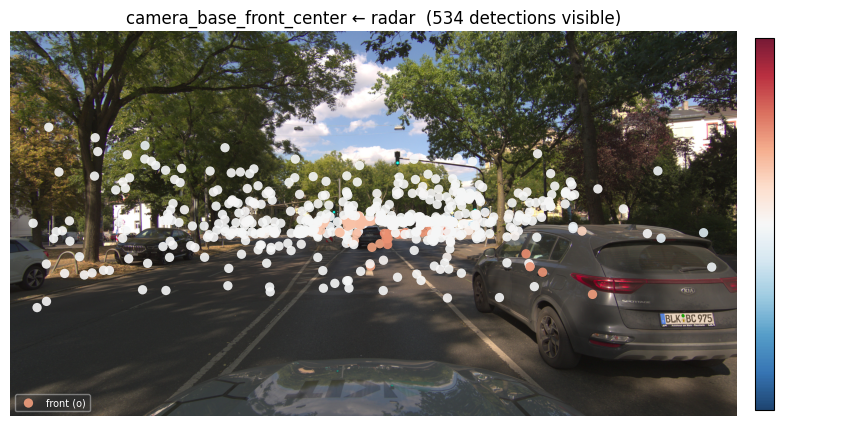

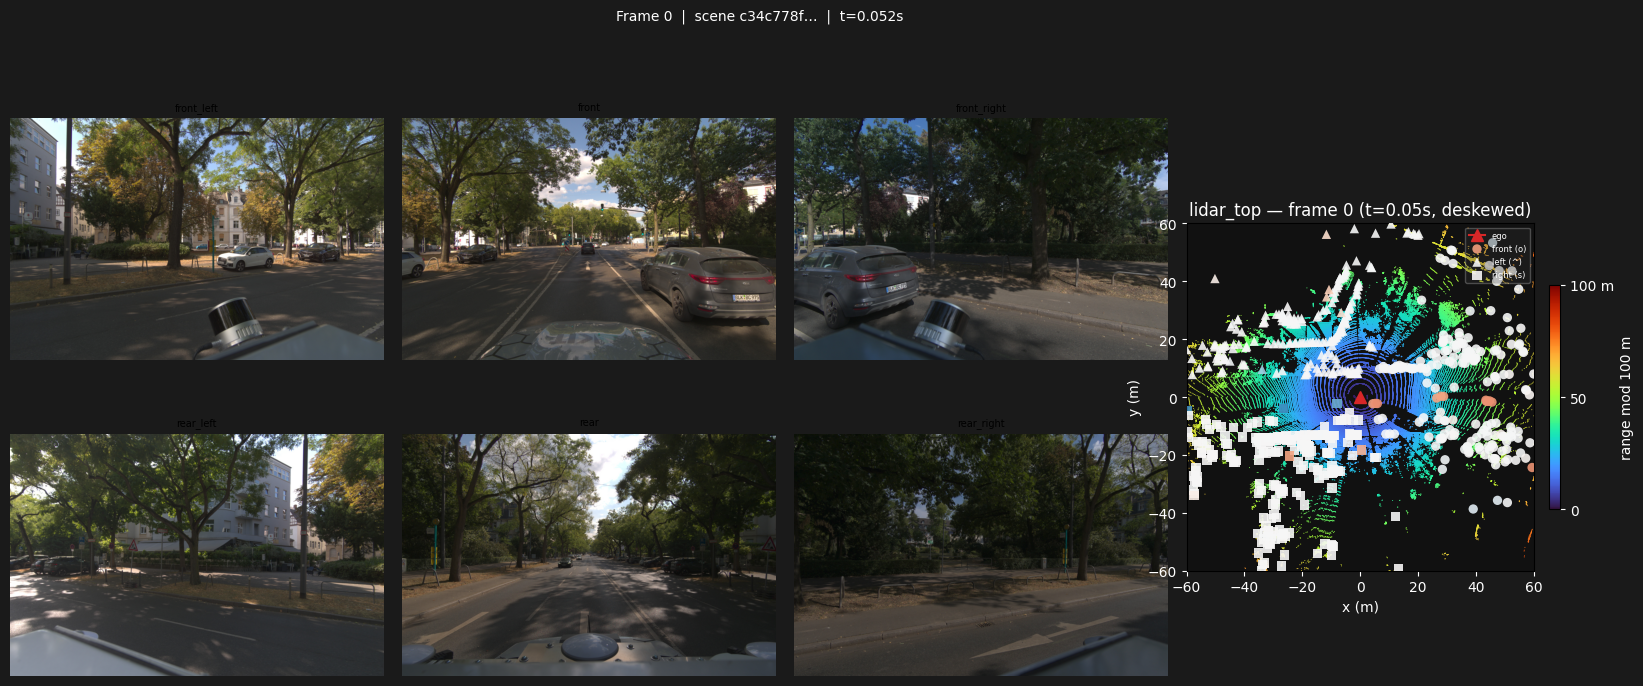

In [36]:
import matplotlib.pyplot as plt
from kitscenes.visualization import (
    render_frame_overview,
    render_radar_bev,
    render_radar_on_camera,
)
%matplotlib inline

if 'frame' not in globals():
    print("Run the frame-construction cell first.")
else:
    if frame.available_radar_names():
        fig, ax = render_radar_bev(frame)
        plt.show()
        plt.close(fig)

        cam_names = frame.available_camera_names()
        if cam_names:
            cam = cam_names[0]
            fig, ax = render_radar_on_camera(frame, cam)
            plt.show()
            plt.close(fig)
        else:
            print("No cameras available, skipping radar_on_camera.")

        fig, axes = render_frame_overview(frame, show_radar=True, range_m=60.0)
        plt.show()
        plt.close(fig)
    else:
        print("No radars are available for this frame.")